# CLARANS sur IRIS

**Dataset** : Iris (`sklearn.datasets.load_iris`)

**Demarche** :
- Chargement des donnees numeriques (4 variables) et normalisation.
- Split explicite **Train (70%) / Validation (15%) / Test (15%)**.
- Optimisation des hyperparametres CLARANS avec **Optuna** sur la validation (score silhouette).
- Re-entrainement final sur Train+Validation, puis evaluation sur Test.

**Remarque** : les labels Iris servent uniquement pour l'evaluation externe (ARI/NMI), pas pour l'apprentissage non supervise.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    pairwise_distances_argmin,
)

from pyclustering.cluster.clarans import clarans
from fast_clarans import FastCLARANS
from pyclustering.utils import timedcall

import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)

# 1) Chargement du dataset IRIS
iris = load_iris(as_frame=True)
X_full = iris.data.copy()
y_full = iris.target.copy()

print(f"Dimension des donnees: {X_full.shape}")
print("Classes:", iris.target_names.tolist())
X_full.head()

Dimension des donnees: (150, 4)
Classes: ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
# 2) Split Train / Validation / Test et normalisation
# 70% train, 15% validation, 15% test
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X_full,
    y_full,
    test_size=0.30,
    random_state=42,
    stratify=y_full,
)

X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_val = scaler.transform(X_val_df)
X_test = scaler.transform(X_test_df)

print(f"Train: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Nb features: {X_train.shape[1]}")

Train: 105 | Validation: 22 | Test: 23
Nb features: 4


In [12]:
# 3) Optimisation Optuna avec Silhouette sur Validation
results = []

def objective(trial):
    k = trial.suggest_int("k", 2, 10)
    numlocal = trial.suggest_int("numlocal", 2, 10)
    maxneighbor = trial.suggest_int("maxneighbor", 5, 80)

    sample_train = X_train.tolist()

    try:
        # On remplace pyclustering par notre version vectorisée Numpy
        model = FastCLARANS(sample_train, k, numlocal, maxneighbor)
        elapsed, _ = timedcall(model.process)


        medoids_idx = model.get_medoids()
        medoids = [sample_train[i] for i in medoids_idx]

        val_labels = pairwise_distances_argmin(X_val, medoids)

        if len(np.unique(val_labels)) > 1:
            sil = silhouette_score(X_val, val_labels)
        else:
            sil = -1.0

    except Exception as e:
        print(f"Trial {trial.number} erreur: {e}")
        return -1.0

    results.append(
        {
            "trial": trial.number,
            "k": k,
            "numlocal": numlocal,
            "maxneighbor": maxneighbor,
            "silhouette_val": sil,
            "time_s": elapsed,
        }
    )

    print(
        f"Trial {trial.number:02d} | k={k}, numlocal={numlocal}, maxneighbor={maxneighbor} "
        f"| silhouette_val={sil:.4f} | {elapsed:.3f}s"
    )
    return sil

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=False)

print("\n=== Meilleurs hyperparametres ===")
print(study.best_trial.params)
print(f"Meilleure silhouette validation: {study.best_value:.4f}")

results_df = pd.DataFrame(results).sort_values("silhouette_val", ascending=False)
results_df.head()

[I 2026-04-20 12:08:01,622] A new study created in memory with name: no-name-0cbf04fc-a390-4aab-875b-2fb086e74354


[I 2026-04-20 12:08:01,715] Trial 0 finished with value: 0.20433422581867633 and parameters: {'k': 5, 'numlocal': 10, 'maxneighbor': 60}. Best is trial 0 with value: 0.20433422581867633.
[I 2026-04-20 12:08:01,731] Trial 1 finished with value: 0.25406888211777323 and parameters: {'k': 7, 'numlocal': 3, 'maxneighbor': 16}. Best is trial 1 with value: 0.25406888211777323.
[I 2026-04-20 12:08:01,781] Trial 2 finished with value: 0.5846602133365666 and parameters: {'k': 2, 'numlocal': 9, 'maxneighbor': 50}. Best is trial 2 with value: 0.5846602133365666.
[I 2026-04-20 12:08:01,843] Trial 3 finished with value: 0.25275727988451596 and parameters: {'k': 8, 'numlocal': 2, 'maxneighbor': 78}. Best is trial 2 with value: 0.5846602133365666.
[I 2026-04-20 12:08:01,856] Trial 4 finished with value: 0.173390549968826 and parameters: {'k': 9, 'numlocal': 3, 'maxneighbor': 18}. Best is trial 2 with value: 0.5846602133365666.
[I 2026-04-20 12:08:01,879] Trial 5 finished with value: 0.402052320006008 

Trial 00 | k=5, numlocal=10, maxneighbor=60 | silhouette_val=0.2043 | 0.086s
Trial 01 | k=7, numlocal=3, maxneighbor=16 | silhouette_val=0.2541 | 0.010s
Trial 02 | k=2, numlocal=9, maxneighbor=50 | silhouette_val=0.5847 | 0.045s
Trial 03 | k=8, numlocal=2, maxneighbor=78 | silhouette_val=0.2528 | 0.042s
Trial 04 | k=9, numlocal=3, maxneighbor=18 | silhouette_val=0.1734 | 0.005s
Trial 05 | k=3, numlocal=4, maxneighbor=44 | silhouette_val=0.4021 | 0.015s
Trial 06 | k=5, numlocal=4, maxneighbor=51 | silhouette_val=0.2041 | 0.037s


[I 2026-04-20 12:08:01,945] Trial 7 finished with value: 0.48495052841474584 and parameters: {'k': 3, 'numlocal': 4, 'maxneighbor': 32}. Best is trial 2 with value: 0.5846602133365666.
[I 2026-04-20 12:08:01,974] Trial 8 finished with value: 0.23938653647333855 and parameters: {'k': 6, 'numlocal': 9, 'maxneighbor': 20}. Best is trial 2 with value: 0.5846602133365666.
[I 2026-04-20 12:08:01,987] Trial 9 finished with value: 0.14401903327133825 and parameters: {'k': 6, 'numlocal': 7, 'maxneighbor': 8}. Best is trial 2 with value: 0.5846602133365666.
[I 2026-04-20 12:08:02,047] Trial 10 finished with value: 0.5846602133365666 and parameters: {'k': 2, 'numlocal': 7, 'maxneighbor': 69}. Best is trial 2 with value: 0.5846602133365666.
[I 2026-04-20 12:08:02,103] Trial 11 finished with value: 0.5846602133365666 and parameters: {'k': 2, 'numlocal': 7, 'maxneighbor': 70}. Best is trial 2 with value: 0.5846602133365666.


Trial 07 | k=3, numlocal=4, maxneighbor=32 | silhouette_val=0.4850 | 0.018s
Trial 08 | k=6, numlocal=9, maxneighbor=20 | silhouette_val=0.2394 | 0.022s
Trial 09 | k=6, numlocal=7, maxneighbor=8 | silhouette_val=0.1440 | 0.006s
Trial 10 | k=2, numlocal=7, maxneighbor=69 | silhouette_val=0.5847 | 0.035s
Trial 11 | k=2, numlocal=7, maxneighbor=70 | silhouette_val=0.5847 | 0.035s


...

[I 2026-04-20 12:08:04,372] Trial 44 finished with value: 0.41168966026962295 and parameters: {'k': 4, 'numlocal': 5, 'maxneighbor': 25}. Best is trial 2 with value: 0.5846602133365666.
[I 2026-04-20 12:08:04,440] Trial 45 finished with value: 0.5846602133365666 and parameters: {'k': 2, 'numlocal': 7, 'maxneighbor': 45}. Best is trial 2 with value: 0.5846602133365666.
[I 2026-04-20 12:08:04,521] Trial 46 finished with value: 0.48495052841474584 and parameters: {'k': 3, 'numlocal': 8, 'maxneighbor': 69}. Best is trial 2 with value: 0.5846602133365666.


Trial 44 | k=4, numlocal=5, maxneighbor=25 | silhouette_val=0.4117 | 0.021s
Trial 45 | k=2, numlocal=7, maxneighbor=45 | silhouette_val=0.5847 | 0.037s
Trial 46 | k=3, numlocal=8, maxneighbor=69 | silhouette_val=0.4850 | 0.051s


[I 2026-04-20 12:08:04,624] Trial 47 finished with value: 0.201852466167861 and parameters: {'k': 10, 'numlocal': 6, 'maxneighbor': 72}. Best is trial 2 with value: 0.5846602133365666.
[I 2026-04-20 12:08:04,668] Trial 48 finished with value: 0.48495052841474584 and parameters: {'k': 3, 'numlocal': 10, 'maxneighbor': 10}. Best is trial 2 with value: 0.5846602133365666.
[I 2026-04-20 12:08:04,727] Trial 49 finished with value: 0.5846602133365666 and parameters: {'k': 2, 'numlocal': 7, 'maxneighbor': 55}. Best is trial 2 with value: 0.5846602133365666.


Trial 47 | k=10, numlocal=6, maxneighbor=72 | silhouette_val=0.2019 | 0.072s
Trial 48 | k=3, numlocal=10, maxneighbor=10 | silhouette_val=0.4850 | 0.014s
Trial 49 | k=2, numlocal=7, maxneighbor=55 | silhouette_val=0.5847 | 0.027s

=== Meilleurs hyperparametres ===
{'k': 2, 'numlocal': 9, 'maxneighbor': 50}
Meilleure silhouette validation: 0.5847


,trial,k,numlocal,maxneighbor,silhouette_val,time_s
12,12,2,8,61,0.58466,0.040495
2,2,2,9,50,0.58466,0.045286
14,14,2,6,35,0.58466,0.012754
10,10,2,7,69,0.58466,0.034553
11,11,2,7,70,0.58466,0.034827


Temps entrainement final: 0.042s
Silhouette test: 0.6426
ARI test: 0.5158
NMI test: 0.7182


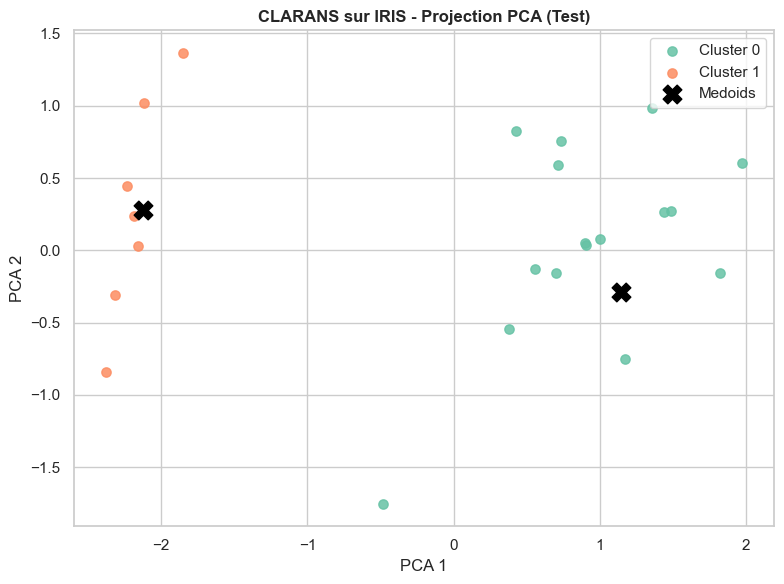

In [14]:
# 4) Entrainement final (Train+Validation) et evaluation sur Test
best_k = study.best_trial.params["k"]
best_numlocal = study.best_trial.params["numlocal"]
best_maxneighbor = study.best_trial.params["maxneighbor"]

X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

final_model = FastCLARANS(
    X_train_val.tolist(),
    best_k,
    best_numlocal,
    best_maxneighbor,
)
final_time, _ = timedcall(final_model.process)

final_medoids_idx = final_model.get_medoids()
final_medoids = X_train_val[final_medoids_idx]

test_labels = pairwise_distances_argmin(X_test, final_medoids)

if len(np.unique(test_labels)) > 1:
    test_sil = silhouette_score(X_test, test_labels)
else:
    test_sil = np.nan

ari = adjusted_rand_score(y_test, test_labels)
nmi = normalized_mutual_info_score(y_test, test_labels)

print(f"Temps entrainement final: {final_time:.3f}s")
print(f"Silhouette test: {test_sil:.4f}")
print(f"ARI test: {ari:.4f}")
print(f"NMI test: {nmi:.4f}")

# Visualisation 2D par PCA
pca = PCA(n_components=2, random_state=42)
X_train_val_2d = pca.fit_transform(X_train_val)
X_test_2d = pca.transform(X_test)
medoids_2d = pca.transform(final_medoids)

plt.figure(figsize=(8, 6))
palette = sns.color_palette("Set2", n_colors=best_k)

for cluster_id in range(best_k):
    mask = test_labels == cluster_id
    if np.any(mask):
        plt.scatter(
            X_test_2d[mask, 0],
            X_test_2d[mask, 1],
            s=45,
            color=palette[cluster_id],
            alpha=0.85,
            label=f"Cluster {cluster_id}",
        )

plt.scatter(
    medoids_2d[:, 0],
    medoids_2d[:, 1],
    marker="X",
    s=180,
    color="black",
    label="Medoids",
    zorder=5,
)

plt.title("CLARANS sur IRIS - Projection PCA (Test)", fontweight="bold")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(loc="best")
plt.tight_layout()
plt.show()